# Build the WGAST training-day manifest

For each city we want a list of **training-eligible days** for the WGAST
secondary model. A day `d0` is eligible iff:

1. **MODIS LST is clear over the AOI on `d0`** — this is the only input WGAST
   needs on the prediction day itself.
2. **There exists a past reference day `t0 < d0` on which Sentinel-2 *and*
   Landsat 8 *and* MODIS were all simultaneously clear** — this is the
   "reference snapshot" t0 that WGAST consumes as a bundle.
3. **The gap `d0 - t0` is at most `max_gap_days`** (default 30) — otherwise
   the reference scene is too stale to trust.

The output is a parquet file at `data/manifest_{city}.parquet` with one row
per `(d0, t0)` pair. Downstream feature builders read this file.


In [1]:
# --- Imports & configuration --------------------------------------------------
import sys, os
sys.path.append(os.path.abspath('..'))  # let us import the data_download package

import numpy as np
import pandas as pd
from bisect import bisect_left

from data_download.Sentinel2Processor import Sentinel2Processor
from data_download.Landsat8Processor  import Landsat8Processor
from data_download.MODISProcessor     import MODISProcessor

# AOI = bounding box [west, south, east, north]. Uncomment ONE city.
# roi = [1.8352731328559473, 47.844911277451844, 1.99343366332974, 47.95130583226066]   # Orleans
roi = [28.963878734763104, 40.99138522259559, 29.122039265236896, 41.09777977740441]    # Istanbul
# roi = [31.156619734763103, 29.991202722595592, 31.314780265236896, 30.09759727740441]  # Cairo
# roi = [-3.7828802652368965, 40.36360272259559, -3.6247197347631035, 40.46999727740441] # Madrid
# roi = [12.413119734763104, 41.83700272259559, 12.571280265236896, 41.94339727740441]   # Rome

city            = "Istanbul"
start_date      = "2017-03-28"   # Sentinel-2 SR archive earliest reliable date
end_date        = "2026-04-01"

pixel_threshold = 80   # % of valid (non-cloudy) pixels required over AOI
max_gap_days    = 50   # max staleness allowed for the t0 reference snapshot


In [2]:
# --- MODIS: needed at d0 (target) AND at t0 (reference) -----------------------
# MODIS LST, 1 km, daily revisit. The d0 candidates come from here.

modis = MODISProcessor(start_date=start_date, end_date=end_date, bounds=roi)

modis_coll          = modis.get_MODIS_collection()
modis_coll_filtered = modis.filter_disponible_images(modis_coll, pixel_threshold)
modis_lst           = modis.get_LST(modis_coll_filtered)

# MODIS timestamps come out as "YYYY-MM-DD HH:MM:SS" — strip the time-of-day.
modis_times = modis.get_formatted_times(modis_coll_filtered)
dates_modis = np.array([t.split(" ")[0] for t in modis_times])

print(f"MODIS clear days over AOI: {len(dates_modis)}")


MODIS clear days over AOI: 1090


In [3]:
# --- Landsat 8: needed at t0 only ---------------------------------------------
# Landsat 8 LST + 3 indices, 30 m, ~16-day revisit.

landsat = Landsat8Processor(start_date=start_date, end_date=end_date, bounds=roi)

landsat_coll          = landsat.get_Landsat_collection()
landsat_coll_filtered = landsat.filter_disponible_images(landsat_coll, pixel_threshold)
landsat_lst_idx       = landsat.get_LST_index(landsat_coll_filtered)

# Landsat timestamps come out as "YYYY-MM-DDTHH:MM:SS" — split on the "T".
landsat_times = landsat.get_times(landsat_lst_idx)
dates_landsat = np.array([t.split("T")[0] for t in landsat_times])

print(f"Landsat 8 clear days over AOI: {len(dates_landsat)}")


Landsat 8 clear days over AOI: 167


In [4]:
# --- Sentinel-2: needed at t0 only --------------------------------------------
# Sentinel-2 indices (NDVI/NDWI/NDBI), 10 m, 5-day revisit.

sentinel = Sentinel2Processor(start_date=start_date, end_date=end_date, bounds=roi)

sentinel_coll          = sentinel.get_Sentinel2_collection()
sentinel_coll_filtered = sentinel.filter_disponible_images(sentinel_coll, pixel_threshold)
sentinel_indices       = sentinel.get_index(sentinel_coll_filtered)

# Same "YYYY-MM-DDTHH:MM:SS" format as Landsat.
sentinel_times = sentinel.get_times(sentinel_indices)
dates_sentinel = np.array([t.split("T")[0] for t in sentinel_times])

print(f"Sentinel-2 clear days over AOI: {len(dates_sentinel)}")


Sentinel-2 clear days over AOI: 448


## Build the manifest

Two simple set operations + one loop:

1. **t0 pool** = `dates_sentinel ∩ dates_landsat ∩ dates_modis` (days where all
   three satellites are simultaneously clear).
2. For each `d0` in `dates_modis`, use `bisect_left` to find the most recent
   `t0 < d0` in the pool. Drop the row if no such t0 exists or if the gap is
   greater than `max_gap_days`.

Using `pd.Timestamp` for the date math — never subtract date *strings*.


In [6]:
# --- Build the (d0, t0) manifest ----------------------------------------------

# Step 1: pool of valid reference dates t0 (3-way clear days), sorted ascending.
t0_pool = sorted(set(dates_sentinel) & set(dates_landsat) & set(dates_modis))
print(f"t0 pool (S2 AND Landsat AND MODIS all clear): {len(t0_pool)} days")

# Convert to pd.Timestamp once so we can do real date arithmetic.
# (Cast via str() because numpy.str_ isn't accepted by pd.Timestamp directly.)
t0_pool_ts    = [pd.Timestamp(str(d)) for d in t0_pool]
d0_candidates = sorted({pd.Timestamp(str(d)) for d in dates_modis})

# Step 2: pair each d0 with the most recent valid t0.
rows = []
for d0 in d0_candidates:
    # bisect_left gives the insertion point for d0; the entry just BEFORE it is
    # the most recent t0 strictly less than d0.
    i = bisect_left(t0_pool_ts, d0) - 1
    if i < 0:
        continue                              # no past t0 exists yet
    t0  = t0_pool_ts[i]
    gap = (d0 - t0).days
    if gap > max_gap_days:
        continue                              # reference is too stale
    rows.append({"region": city, "d0": d0, "t0": t0, "gap_days": gap})

manifest = pd.DataFrame(rows)
print(f"\nManifest rows: {len(manifest)}")
print(manifest.head())
print("\nGap-days distribution:")
print(manifest["gap_days"].describe())


t0 pool (S2 AND Landsat AND MODIS all clear): 27 days

Manifest rows: 493
     region         d0         t0  gap_days
0  Istanbul 2017-06-11 2017-06-07         4
1  Istanbul 2017-06-13 2017-06-07         6
2  Istanbul 2017-06-14 2017-06-07         7
3  Istanbul 2017-06-16 2017-06-07         9
4  Istanbul 2017-06-17 2017-06-07        10

Gap-days distribution:
count    493.000000
mean      22.953347
std       14.208517
min        1.000000
25%       10.000000
50%       23.000000
75%       35.000000
max       50.000000
Name: gap_days, dtype: float64


In [7]:
# --- Save manifest ------------------------------------------------------------
os.makedirs("data", exist_ok=True)
manifest_path = f"data/manifest_{city}.parquet"
manifest.to_parquet(manifest_path, index=False)
print(f"Saved -> {manifest_path}")


Saved -> data/manifest_Istanbul.parquet


## (Optional) Export the rasters the manifest points at

Export only what the manifest actually uses:

- **MODIS LST at every `d0`** (the daily target-day input)
- **MODIS LST at every `t0`** (the reference-day MODIS input)
- **Landsat 8 LST+indices at every `t0`**
- **Sentinel-2 indices at every `t0`**

`filter_by_common_dates` keeps only images whose date is in a given list — same
helper used in `01_data_download.ipynb`. Note that `Sentinel2Processor` does not
define this method itself, so we borrow the MODIS processor's implementation
(it's a generic server-side date filter on an `ee.ImageCollection`).


In [ ]:
# --- Export rasters -----------------------------------------------------------
# Each block skips the actual export if the target directory already has files
# (so re-running the cell is safe and doesn't re-download). Delete a folder
# to force a fresh export of that sensor.
import geemap

d0_dates = manifest["d0"].dt.strftime("%Y-%m-%d").unique()
t0_dates = manifest["t0"].dt.strftime("%Y-%m-%d").unique()


def export_if_missing(collection, out_dir, scale, region, label):
    """Export an ee.ImageCollection to out_dir unless files are already there."""
    os.makedirs(out_dir, exist_ok=True)
    if os.listdir(out_dir):
        print(f"[skip] {label}: {out_dir} already has files")
        return
    print(f"[export] {label} -> {out_dir}")
    geemap.ee_export_image_collection(
        collection, out_dir=out_dir, scale=scale, region=region
    )


# MODIS at d0
modis_d0_coll = modis.filter_by_common_dates(modis_lst, d0_dates)
export_if_missing(
    modis_d0_coll,
    f"data/raw_secondary_model/MODIS_d0_{city}",
    scale=1000, region=modis.aoi, label="MODIS@d0",
)

# MODIS at t0
modis_t0_coll = modis.filter_by_common_dates(modis_lst, t0_dates)
export_if_missing(
    modis_t0_coll,
    f"data/raw_secondary_model/MODIS_t0_{city}",
    scale=1000, region=modis.aoi, label="MODIS@t0",
)

# Landsat 8 at t0
landsat_t0_coll = modis.filter_by_common_dates(landsat_lst_idx, t0_dates)
export_if_missing(
    landsat_t0_coll,
    f"data/raw_secondary_model/Landsat8_t0_{city}",
    scale=30, region=landsat.aoi, label="Landsat8@t0",
)

# Sentinel-2 at t0
sentinel_t0_coll = modis.filter_by_common_dates(sentinel_indices, t0_dates)
export_if_missing(
    sentinel_t0_coll,
    f"data/raw_secondary_model/Sentinel2_t0_{city}",
    scale=10, region=sentinel.aoi, label="Sentinel2@t0",
)

print("Done.")


shape: (1, 13, 18) dtype: float64 range: 0.0 19.810000000000002


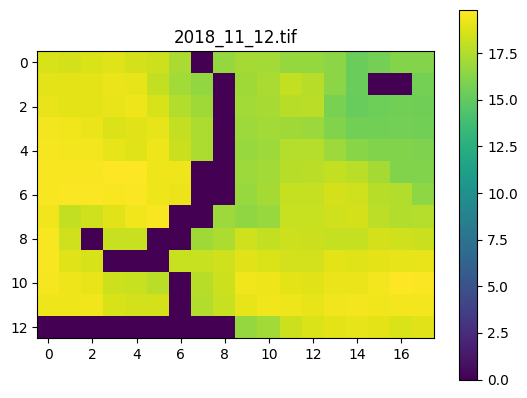

In [28]:
import rasterio, matplotlib.pyplot as plt

path = "data/raw_secondary_model/MODIS_d0_Istanbul/2018_11_12.tif"
with rasterio.open(path) as src:
    arr = src.read()
    print("shape:", arr.shape, "dtype:", arr.dtype, "range:", arr.min(), arr.max())
    plt.imshow(arr[0]); plt.colorbar(); plt.title(path.split("/")[-1])